# EconoCausal – Week 1 & Week 2 Results

## Dynamic Pricing via Double Machine Learning

### Objective

Develop a causal machine learning framework for dynamic pricing using
Double Machine Learning (DML) and DoWhy.

### Week 1
- Project architecture and Python environment setup
- Pricing dataset generation
- Feature and treatment definition
- Initial causal modeling pipeline

### Week 2
- Double Machine Learning implementation using EconML
- LightGBM nuisance models
- DoWhy causal identification
- Causal price-effect estimation
- Initial revenue-based price optimization

In [1]:
import sys
print(sys.executable)


C:\Users\SHANMUGARAJ D\Music\econocausal-dynamic-pricing\.venv\Scripts\python.exe


In [5]:
import pandas as pd

df = pd.read_csv("../data/pricing_data.csv")

print("Dataset shape:", df.shape)
display(df.head())
display(df.describe())

Dataset shape: (2000, 6)


,price,competitor_price,demand,seasonality,customer_segment,sales
0,127.395605,134.273197,744.489974,0.455476,2,760.125658
1,93.887844,94.638949,421.404036,0.118858,1,723.379124
2,135.859792,145.297516,866.681070,0.569173,0,844.168045
3,119.736803,115.079459,316.879444,0.156429,2,655.009678
4,59.417735,61.589887,584.554141,0.060958,2,782.531151


,price,competitor_price,demand,seasonality,customer_segment,sales
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,100.283672,99.322283,539.360787,0.499054,1.00400,725.315582
std,29.044884,28.985169,256.018717,0.288472,0.82178,149.778481
min,50.051874,50.064230,100.282978,0.000417,0.00000,211.878705
25%,74.407061,74.582483,317.322381,0.254085,0.00000,619.666830
50%,99.601128,99.504578,534.968873,0.501760,1.00000,727.627708
75%,126.121292,124.565474,758.077624,0.741493,2.00000,828.480206
max,149.942191,149.976534,999.743366,0.999977,2.00000,1157.948475


## DML Causal Effect

The Double Machine Learning model was implemented using EconML with LightGBM
as the nuisance models.

The estimated average causal effect of price on sales was:

**DML causal effect = -2.4611**

This indicates that, under the synthetic data-generating process, increasing
price has a negative causal effect on sales.

In [3]:
dml_effect = -2.4611

print(f"DML estimated causal price effect: {dml_effect:.4f}")

DML estimated causal price effect: -2.4611


## DoWhy Causal Identification

DoWhy was used to identify the causal estimand using a backdoor adjustment
with the observed common causes:

- Competitor price
- Demand
- Seasonality
- Customer segment

The estimated causal effect was:

**DoWhy causal effect = -2.4748**

The DML and DoWhy estimates are close to each other and to the synthetic
ground-truth effect of approximately **-2.50**.

## Dynamic Pricing Optimization

The estimated causal price effect was incorporated into an initial revenue
optimization framework.

- Baseline price: **100.28**
- Baseline sales: **725.32**
- Causal price effect: **-2.4611**
- Initial optimal price: **150.00**
- Expected sales: **602.96**
- Expected revenue: **90,443.63**

The optimizer currently reaches the upper boundary of the observed price range.
This is expected from the initial linear demand-revenue formulation and will be
refined using a real-world pricing dataset and a more realistic demand model.

In [4]:
optimization_results = {
    "Baseline Price": 100.28,
    "Baseline Sales": 725.32,
    "Causal Price Effect": -2.4611,
    "Optimal Price": 150.00,
    "Expected Sales": 602.96,
    "Expected Revenue": 90443.63,
}

pd.DataFrame(
    optimization_results.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Baseline Price,100.2800
1,Baseline Sales,725.3200
2,Causal Price Effect,-2.4611
3,Optimal Price,150.0000
4,Expected Sales,602.9600
5,Expected Revenue,90443.6300


## Week 1–2 Conclusion

The EconoCausal prototype successfully demonstrates a complete causal pricing
pipeline:

**Pricing Data → Causal Identification → Double Machine Learning → Causal
Price Effect → Revenue Optimization**

The DML estimate (-2.4611) and DoWhy estimate (-2.4748) are both close to the
known synthetic effect (-2.50), providing initial validation of the causal
estimation pipeline.

### Future Work

1. Evaluate the framework using a publicly available real-world pricing and
   demand dataset.
2. Improve the demand-response model.
3. Develop contextual treatment effects for customer and market conditions.
4. Improve dynamic price optimization under realistic business constraints.

## Graph 1: Price vs Sales

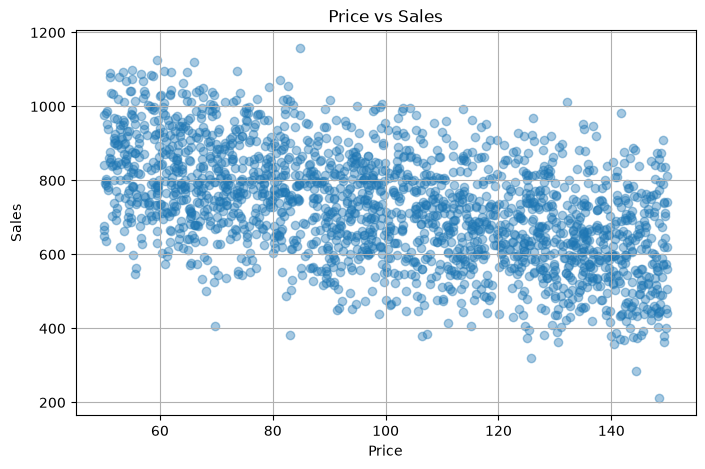

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["price"],
    df["sales"],
    alpha=0.4
)

plt.xlabel("Price")
plt.ylabel("Sales")
plt.title("Price vs Sales")

plt.grid(True)
plt.show()

## Graph 2: Price vs Expected Revenue

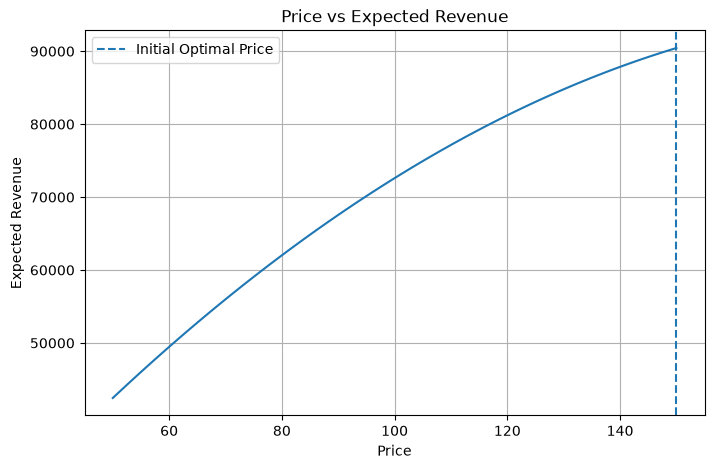

In [6]:
import numpy as np

causal_effect = -2.4611
baseline_price = 100.28
baseline_sales = 725.32

prices = np.linspace(50, 150, 101)

expected_sales = (
    baseline_sales
    + causal_effect * (prices - baseline_price)
)

expected_revenue = prices * expected_sales

plt.figure(figsize=(8, 5))

plt.plot(
    prices,
    expected_revenue
)

plt.axvline(
    150,
    linestyle="--",
    label="Initial Optimal Price"
)

plt.xlabel("Price")
plt.ylabel("Expected Revenue")
plt.title("Price vs Expected Revenue")

plt.legend()
plt.grid(True)
plt.show()

## DoWhy Causal Audit – Refutation Tests

DoWhy refutation tests were performed to validate the robustness of the causal estimate.

- Original causal effect: **-2.4748**
- Random common cause effect: **-2.4746**
- Random common cause p-value: **0.88**
- Placebo treatment effect: **0.0061**
- Placebo treatment p-value: **0.84**

The random common cause produced almost no change in the estimated effect, while the placebo treatment produced an effect close to zero. These results provide supporting evidence for the robustness of the causal estimate.

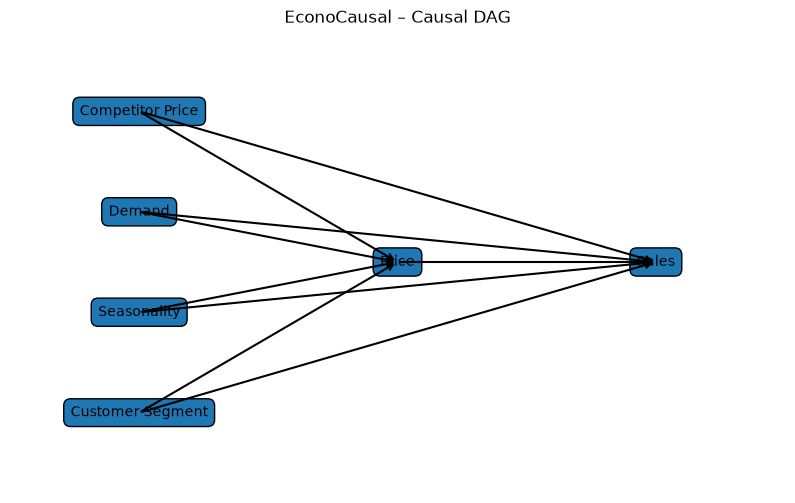

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Node positions
positions = {
    "Competitor Price": (0, 3),
    "Demand": (0, 2),
    "Seasonality": (0, 1),
    "Customer Segment": (0, 0),
    "Price": (2, 1.5),
    "Sales": (4, 1.5),
}

# Draw nodes
for node, (x, y) in positions.items():
    ax.text(
        x, y, node,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.5")
    )

# Draw causal arrows
causal_edges = [
    ("Competitor Price", "Price"),
    ("Competitor Price", "Sales"),
    ("Demand", "Price"),
    ("Demand", "Sales"),
    ("Seasonality", "Price"),
    ("Seasonality", "Sales"),
    ("Customer Segment", "Price"),
    ("Customer Segment", "Sales"),
    ("Price", "Sales"),
]

for source, target in causal_edges:
    x1, y1 = positions[source]
    x2, y2 = positions[target]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

ax.set_title("EconoCausal – Causal DAG")
ax.set_xlim(-1, 5)
ax.set_ylim(-0.8, 3.8)
ax.axis("off")
plt.show()

## Causal DAG

The causal DAG defines **price** as the treatment and **sales** as the outcome. Competitor price, demand, seasonality and customer segment are treated as observed common causes and are included for causal adjustment.

In [6]:
from econml.dml import CausalForestDML
from lightgbm import LGBMRegressor
import numpy as np

# Features used for heterogeneous treatment effects
X = df[
    ["competitor_price", "demand", "seasonality", "customer_segment"]
]

T = df["price"]
Y = df["sales"]

# Causal Forest for heterogeneous treatment effects
ite_model = CausalForestDML(
    model_y=LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    model_t=LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    discrete_treatment=False,
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42
)

ite_model.fit(Y, T, X=X)

# Effect of increasing price from 100 to 101
ite = ite_model.effect(
    X,
    T0=100,
    T1=101
)

print("=== Individual Treatment Effects ===")
print(f"Mean ITE: {np.mean(ite):.4f}")
print(f"Minimum ITE: {np.min(ite):.4f}")
print(f"Maximum ITE: {np.max(ite):.4f}")

print("\nFirst 10 individual effects:")
print(ite[:10])

=== Individual Treatment Effects ===
Mean ITE: -2.3941
Minimum ITE: -2.7893
Maximum ITE: -2.0674

First 10 individual effects:
[-2.50069243 -2.7374827  -2.37804668 -2.58659456 -2.52563747 -2.3675776
 -2.26070809 -2.42425378 -2.37894121 -2.29674269]


## Individual Treatment Effects (ITE)

A Causal Forest was used to estimate heterogeneous treatment effects for an increase in price from 100 to 101.

- Mean ITE: **-2.3941**
- Minimum ITE: **-2.7893**
- Maximum ITE: **-2.0674**

The variation in ITE shows that the estimated effect of a price increase differs across observations and market/customer conditions.